# 07 — A real-solver thermal surrogate (Darcy-FNO recipe on Kratos)

The recipe of PhysicsNeMo's *Darcy Flow FNO* and *Datacenter Thermal Surrogate*
examples, driven by a **real Kratos solver**: `ConvectionDiffusionApplication`
solves stationary heat conduction on the unit square for a sweep of conductivities,
`grid_bridge` turns the solutions into voxel grids, a small `FNO` learns
conductivity-grid → temperature-grid, and `GridInferenceProcess` deploys it back
onto the mesh — validated with `ValidationMetricsProcess` against a held-out real
solve.

> **Prerequisites**: a compiled Kratos with `PhysicsNeMoApplication`,
> `ConvectionDiffusionApplication` and `LinearSolversApplication` enabled, plus:
>
> ```bash
> export PYTHONPATH=/path/to/Kratos/bin/Release
> export LD_LIBRARY_PATH=/path/to/Kratos/bin/Release/libs:$LD_LIBRARY_PATH
> pip install torch nvidia-physicsnemo
> ```
>
> Everything below runs on CPU; outputs are written to `./output/`.

In [1]:
import sys
from pathlib import Path

import numpy
import torch
import matplotlib.pyplot as plt

import KratosMultiphysics as Kratos
import KratosMultiphysics.kratos_utilities as kratos_utils

if not kratos_utils.CheckIfApplicationsAvailable("ConvectionDiffusionApplication", "LinearSolversApplication"):
    raise RuntimeError(
        "This notebook needs ConvectionDiffusionApplication and LinearSolversApplication "
        "compiled into Kratos (add them with add_app in your configure script).")

from KratosMultiphysics.PhysicsNeMoApplication.bridges import grid_bridge
from KratosMultiphysics.PhysicsNeMoApplication.processes.inference import grid_inference_process
from KratosMultiphysics.PhysicsNeMoApplication.processes import validation_metrics_process
from physicsnemo.models.fno import FNO

# The reusable in-memory thermal case shipped with the application's tests.
sys.path.insert(0, str(Path(Kratos.__path__[0]).parent.parent.parent
                       / "applications" / "PhysicsNeMoApplication" / "tests" / "kratos_solver_cases"))
import thermal_case

torch.manual_seed(0)
numpy.random.seed(0)
Path("output").mkdir(exist_ok=True)
from KratosMultiphysics import pyvista_utilities as pv_utils

 |  /           |                  
 ' /   __| _` | __|  _ \   __|    
 . \  |   (   | |   (   |\__ \  
_|\_\_|  \__,_|\__|\___/ ____/
           Multi-Physics 10.4."2"-physicsnemo-application-e03638205c2-Release-x86_64
           Compiled for GNU/Linux and Python3.12 with GCC-13.3
Compiled with threading and MPI support. Threading support with OpenMP.
Maximum number of threads: 2.
Running without MPI.
Importing    KratosPhysicsNeMoApplication 
 ______  _                _            ______        ______                           _ _                 _            
(_____ \| |              (_)          |  ___ \      |  ___ \         /\              | (_)           _   (_)            
 _____) ) | _  _   _  ___ _  ____  ___| |   | | ____| | _ | | ___   /  \  ____  ____ | |_  ____ ____| |_  _  ___  ____  
|  ____/| || \| | | |/___) |/ ___)/___) |   | |/ _  ) || || |/ _ \ / /\ \|  _ \|  _ \| | |/ ___) _  |  _)| |/ _ \|  _ \
| |     | | | | |_| |___ | ( (___|___ | |   | ( (/ /| || || | |_| | |

/home/vicente/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Real solves across a conductivity sweep

Each sample is one actual `ConvectionDiffusionAnalysis` run: `-k Δu = f` with
`u = 0` on the boundary. The grid bridge samples both the conductivity field (the
surrogate input) and the solved temperature (the target) on a 16×16×2 grid (the
case is 2D; two z-planes keep the 3D grid machinery happy).

In [2]:
GRID_SHAPE = (16, 16, 2)
BOX = (numpy.array([0.0, 0.0, -0.05]), numpy.array([1.0, 1.0, 0.05]))
DIVISIONS = 12

def solve_real_case(conductivity):
    model = Kratos.Model()
    analysis = thermal_case.CreateThermalAnalysis(
        model, conductivity=conductivity, heat_flux=1.0, divisions=DIVISIONS)
    analysis.Run()
    return model, model["ThermalModelPart"]

train_pairs = []
for conductivity in (0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0):
    _, model_part = solve_real_case(conductivity)
    k_grid, _ = grid_bridge.SampleFieldsOnGrid(
        model_part, [("CONDUCTIVITY", "node_historical")], GRID_SHAPE, bounding_box=BOX)
    t_grid, _ = grid_bridge.SampleFieldsOnGrid(
        model_part, [("TEMPERATURE", "node_historical")], GRID_SHAPE, bounding_box=BOX)
    train_pairs.append((torch.from_numpy(k_grid).float(), torch.from_numpy(t_grid).float()))
print(len(train_pairs), "real solves sampled onto", GRID_SHAPE, "grids")

Importing    KratosConvectionDiffusionApplication 
 KRATOS ___ ___  _  ___   __   ___ ___ ___ ___ 
       / __/ _ || || | | / /__|   |_ _| __| __|
      | (_| (_) | .` || V /___| |) | || _|| _| 
       |___|___/|_||_| |_/    |___/___|_| |_|  APPLICATION
ConvectionDiffusionStationarySolver: 'surface_source_variable' in 'convection_diffusion_variables' not defined, taking default 'FACE_HEAT_FLUX'. 
ConvectionDiffusionStationarySolver: 'projection_variable' in 'convection_diffusion_variables' not defined, taking default 'PROJECTED_SCALAR1'. 
ConvectionDiffusionStationarySolver: 'convection_variable' in 'convection_diffusion_variables' not defined, taking default 'CONVECTION_VELOCITY'. 
ConvectionDiffusionStationarySolver: 'gradient_variable' in 'convection_diffusion_variables' not defined, taking default 'TEMPERATURE_GRADIENT'. 
ConvectionDiffusionStationarySolver: 'transfer_coefficient_variable' in 'convection_diffusion_variables' not defined, taking default 'TRANSFER_COEFFICIENT'. 
Conv

ConvectionDiffusionStationarySolver: 'surface_source_variable' in 'convection_diffusion_variables' not defined, taking default 'FACE_HEAT_FLUX'. 
ConvectionDiffusionStationarySolver: 'projection_variable' in 'convection_diffusion_variables' not defined, taking default 'PROJECTED_SCALAR1'. 
ConvectionDiffusionStationarySolver: 'convection_variable' in 'convection_diffusion_variables' not defined, taking default 'CONVECTION_VELOCITY'. 
ConvectionDiffusionStationarySolver: 'gradient_variable' in 'convection_diffusion_variables' not defined, taking default 'TEMPERATURE_GRADIENT'. 
ConvectionDiffusionStationarySolver: 'transfer_coefficient_variable' in 'convection_diffusion_variables' not defined, taking default 'TRANSFER_COEFFICIENT'. 
ConvectionDiffusionStationarySolver: 'reaction_gradient_variable' in 'convection_diffusion_variables' not defined, taking default 'REACTION'. 
::[ConvectionDiffusionSolver]:: : Construction finished 
ConvectionDiffusionStationarySolver: Construction finished

## Training a small FNO

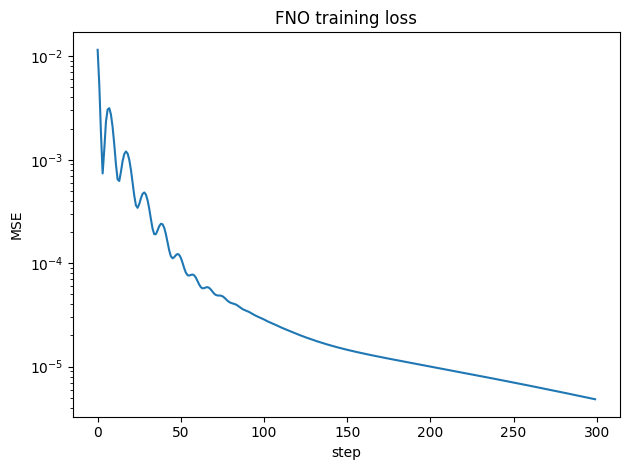

final loss: 4.832250851904973e-06


In [3]:
fno = FNO(in_channels=1, out_channels=1, dimension=3,
          latent_channels=16, num_fno_layers=3, num_fno_modes=[6, 6, 1], padding=2)
optimizer = torch.optim.Adam(fno.parameters(), lr=2e-3)

inputs = torch.stack([pair[0] for pair in train_pairs])
targets = torch.stack([pair[1] for pair in train_pairs])

losses = []
for step in range(300):
    optimizer.zero_grad()
    loss = torch.nn.functional.mse_loss(fno(inputs), targets)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.semilogy(losses); plt.xlabel("step"); plt.ylabel("MSE"); plt.title("FNO training loss")
plt.tight_layout(); plt.savefig("output/fno_loss.png", dpi=120); plt.show()
print("final loss:", losses[-1])
assert losses[-1] < 1e-2, f"training did not converge: final loss {losses[-1]:.3e}"
fno.save("output/thermal_fno.mdlus")

## Deployment on a held-out real solve

An unseen conductivity: Kratos solves it for real (the reference), and
`GridInferenceProcess` predicts the temperature from the conductivity field alone,
writing into non-historical `NODAL_PAUX`. `ValidationMetricsProcess` quantifies the
mismatch.

In [4]:
k_test = 1.25  # not in the training sweep
model, model_part = solve_real_case(k_test)
for node in model_part.Nodes:
    node.SetValue(Kratos.NODAL_PAUX, 0.0)

settings = Kratos.Parameters("""{
    "Parameters": {
        "model_part_name" : "ThermalModelPart",
        "model_settings"  : {
            "checkpoint_file" : "output/thermal_fno.mdlus",
            "checkpoint_type" : "physicsnemo",
            "device"          : "auto"
        },
        "input_fields"    : [ { "variable_name" : "CONDUCTIVITY", "data_location" : "node_historical" } ],
        "output_fields"   : [ { "variable_name" : "NODAL_PAUX",   "data_location" : "node_non_historical" } ],
        "grid_shape"      : [16, 16, 2],
        "bounding_box"    : [0.0, 0.0, -0.05, 1.0, 1.0, 0.05]
    }
}""")
process = grid_inference_process.Factory(settings, model)
model_part.ProcessInfo[Kratos.STEP] = 1
process.ExecuteFinalizeSolutionStep()

metrics_settings = Kratos.Parameters("""{
    "Parameters": {
        "model_part_name"     : "ThermalModelPart",
        "list_of_comparisons" : [{
            "predicted_variable" : "NODAL_PAUX",
            "predicted_location" : "node_non_historical",
            "reference_variable" : "TEMPERATURE",
            "reference_location" : "node_historical",
            "metrics"            : ["rmse", "max_abs_error"]
        }],
        "output_file"         : "output/validation_metrics.json"
    }
}""")
metrics = validation_metrics_process.Factory(metrics_settings, model)
metrics.ExecuteFinalizeSolutionStep()
metrics.ExecuteFinalize()
comparison = metrics.history[0]["NODAL_PAUX_vs_TEMPERATURE"]
print(comparison)
assert comparison["rmse"] < 1e-2, f"surrogate rmse too large: {comparison['rmse']:.3e}"
assert comparison["max_abs_error"] < 5e-2, (
    f"surrogate max abs error too large: {comparison['max_abs_error']:.3e}")

ConvectionDiffusionStationarySolver: 'surface_source_variable' in 'convection_diffusion_variables' not defined, taking default 'FACE_HEAT_FLUX'. 
ConvectionDiffusionStationarySolver: 'projection_variable' in 'convection_diffusion_variables' not defined, taking default 'PROJECTED_SCALAR1'. 
ConvectionDiffusionStationarySolver: 'convection_variable' in 'convection_diffusion_variables' not defined, taking default 'CONVECTION_VELOCITY'. 
ConvectionDiffusionStationarySolver: 'gradient_variable' in 'convection_diffusion_variables' not defined, taking default 'TEMPERATURE_GRADIENT'. 
ConvectionDiffusionStationarySolver: 'transfer_coefficient_variable' in 'convection_diffusion_variables' not defined, taking default 'TRANSFER_COEFFICIENT'. 
ConvectionDiffusionStationarySolver: 'reaction_gradient_variable' in 'convection_diffusion_variables' not defined, taking default 'REACTION'. 
::[ConvectionDiffusionSolver]:: : Construction finished 
ConvectionDiffusionStationarySolver: Construction finished

ValidationMetricsProcess: step 1: NODAL_PAUX_vs_TEMPERATURE: rmse=7.531589e-04, max_abs_error=1.571129e-03 
{'rmse': 0.0007531589439634191, 'max_abs_error': 0.0015711286442146241}
ValidationMetricsProcess: Wrote 1 record(s) to "output/validation_metrics.json". 


## Field comparison

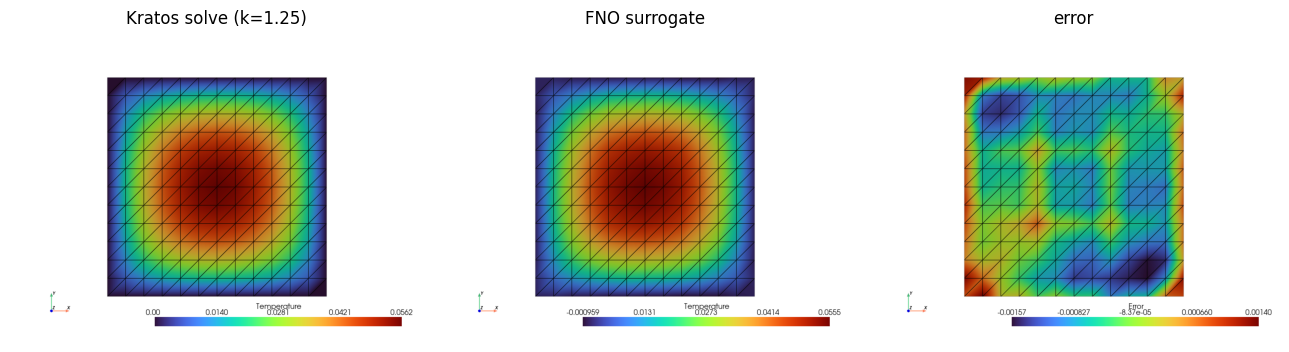

In [5]:
reference = numpy.array([node.GetSolutionStepValue(Kratos.TEMPERATURE) for node in model_part.Nodes])
predicted = numpy.array([node.GetValue(Kratos.NODAL_PAUX) for node in model_part.Nodes])

# NODAL_PAUX already holds the FNO prediction (previous cell); store the
# error into another free nodal scalar so all three fields render the same way.
error = numpy.array([node.GetValue(Kratos.NODAL_PAUX) for node in model_part.Nodes]) - reference
for node, e in zip(model_part.Nodes, error):
    node.SetValue(Kratos.NODAL_ERROR, float(e))

# Each field is a true mesh-aware render (element connectivity, not a
# scattered-point Delaunay triangulation) via the core pyvista bridge.
panels = [
    (Kratos.TEMPERATURE, f"Kratos solve (k={k_test})", "Temperature"),
    (Kratos.NODAL_PAUX,  "FNO surrogate",               "Temperature"),
    (Kratos.NODAL_ERROR, "error",                        "Error"),
]
images = [
    pv_utils.ScreenshotModelPart(model_part, filename=None, name=variable,
                                 label=label, cmap="turbo")
    for variable, _, label in panels
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, img, (_, title, _) in zip(axes, images, panels):
    ax.imshow(img); ax.set_title(title); ax.axis("off")
plt.tight_layout()
plt.savefig("output/fno_fields.png", dpi=120, bbox_inches="tight")
plt.show()

## Where to go from here

- Swap the analytic conductivity sweep for your own case parametrization; the same
  loop works with any `AnalysisStage`.
- The real-solver active-learning template under
  `applications/PhysicsNeMoApplication/tests/kratos_solver_cases/thermal_template/`
  shows the identical case run as an **external subprocess** — the production path
  for expensive solves.
- Availability-gating (`CheckIfApplicationsAvailable`, first cell) is the pattern to
  follow whenever an example depends on other compiled Kratos applications.